# Assignment 3
### PHY408 Winter 26
### Jack Cheng 1010266695

In [61]:
print("Hello")

Hello


***

## Question 1

Recall the Gaussian function defined in lab 1:
$$g(t)=\frac{1}{\sqrt{\pi}t_{H}}e^{-(t/t_{H})^{2}}$$
where $t_{H}$ is the half duration.

**(a) [1 point]** Plot $g(t)$ for $t_{H}=20$ and $t_{H}=40$ sec on the same graph with domain [-100, 100] and $dt=10^{-3}s$.

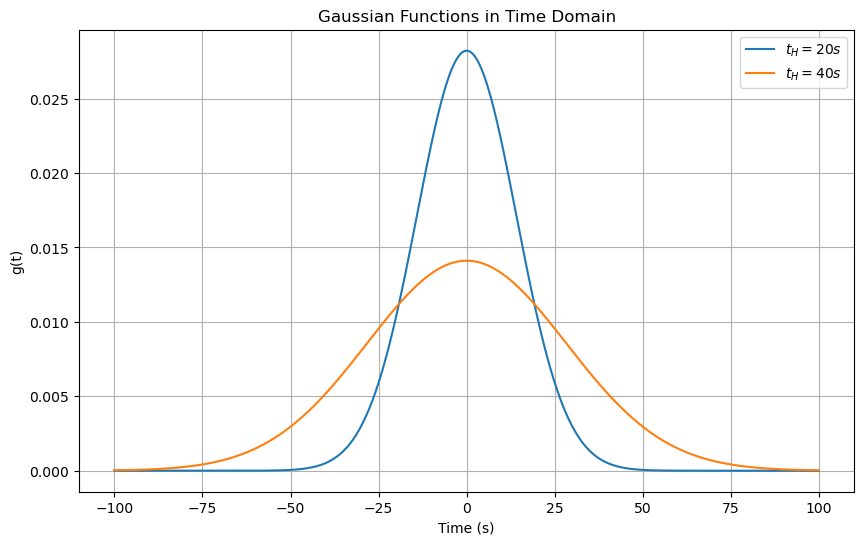

In [62]:
# Question 1, part a
import numpy as np
import matplotlib.pyplot as plt

def gaussian(t, t_h):
    return (1 / (np.sqrt(np.pi) * t_h)) * np.exp(-(t / t_h)**2)

dt = 1e-3
t = np.arange(-100, 100, dt)

g20 = gaussian(t, 20)
g40 = gaussian(t, 40)

plt.figure(figsize=(10, 6))
plt.plot(t, g20, label='$t_H = 20s$')
plt.plot(t, g40, label='$t_H = 40s$')
plt.title('Gaussian Functions in Time Domain')
plt.xlabel('Time (s)')
plt.ylabel('g(t)')
plt.legend()
plt.grid(True)
plt.show()

**(b) [3 points]** The analytical formula for the Fourier transform of $g(t)$ is 
$$G(\omega)=e^{\frac{-\omega^{2}t_{H}^{2}}{4}}$$
Compute the discrete Fourier transform (DFT) for both sampled $g(t)$ time series, and compare them to the analytical $G(\omega)$ for both $t_{H}$ on the same graph. If you calculate a DFT with imaginary components, plot the real and imaginary components on separate plots.

As a guide, we expect that the amplitudes (use `numpy.abs(...)`) of the discrete FT and the continuous FT essentially match. The phase won't necessarily match.


<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_44980\2389235610.py:27: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


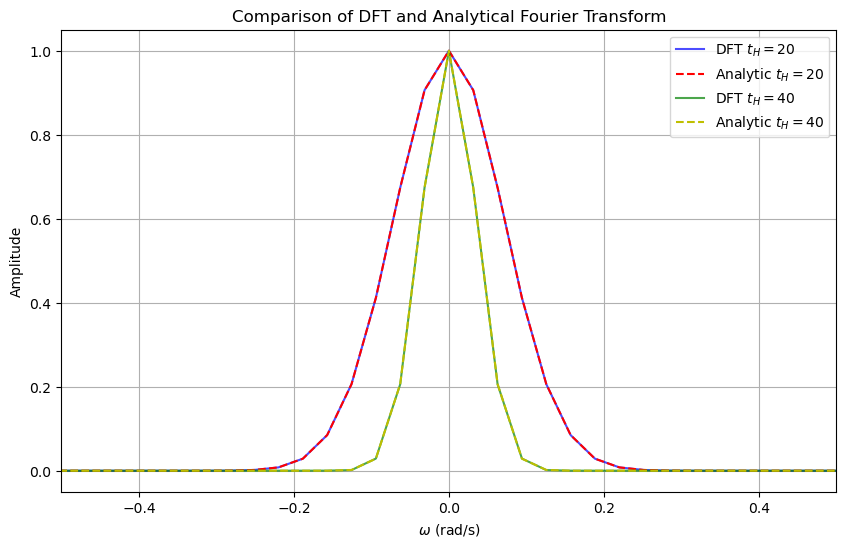

In [63]:
# Question 1, part b
from numpy.fft import fft, fftfreq, fftshift

def analytical_G(omega, t_h):
    return np.exp(-(omega**2 * t_h**2) / 4)

# FFT for tH = 20 and 40
# We multiply by dt to approximate the continuous Fourier Transform integral
G20_dft = fftshift(fft(g20)) * dt
G40_dft = fftshift(fft(g40)) * dt

freqs = fftshift(fftfreq(len(t), d=dt))
omega = 2 * np.pi * freqs

# Analytical
G20_analytic = analytical_G(omega, 20)
G40_analytic = analytical_G(omega, 40)

# Plotting Amplitudes
plt.figure(figsize=(10, 6))
plt.plot(omega, np.abs(G20_dft), 'b-', label='DFT $t_H=20$', alpha=0.7)
plt.plot(omega, G20_analytic, 'r--', label='Analytic $t_H=20$')
plt.plot(omega, np.abs(G40_dft), 'g-', label='DFT $t_H=40$', alpha=0.7)
plt.plot(omega, G40_analytic, 'y--', label='Analytic $t_H=40$')
plt.xlim(-0.5, 0.5) # Focus on the peak
plt.title('Comparison of DFT and Analytical Fourier Transform')
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

**(c) [2 points]** Comment on the effect of filtering a general input time function $f(t)$ by $g(t)$ (i.e. convolution of $f(t)$ with $g(t)$), and explain the difference in filtered output after applying Gaussian functions with $t_{H}=20$ or 40 secs.


**Discussion on Filtering:**
Filtering a signal $f(t)$ by convolving it with $g(t)$ is equivalent to multiplying the signal's Fourier transform $F(\omega)$ by the Gaussian's transform $G(\omega)$. Because $G(\omega)$ is also a Gaussian that decays at higher frequencies, this is considered as a low-pass filter.

The difference between $t_H=20$ and $t_H=40$:
* **$t_H=40$** is wider in the time domain, which means its frequency response $G(\omega)$ is **narrower**. It will filter out more high-frequency content.
* **$t_H=20$** is narrower in time, meaning a wider frequency response. It preserves more high-frequency detail than the 40s window.

***

## Question 2

A continuous time signal $f(t)$ can be truncated into a signal of finite length T by window functions $b(t)$:
$$g(t)=f(t)b(t)$$

**Typical window functions include:**
* **Boxcar function:** $b(t)=\begin{cases}1&0\le t\le T\\ 0&else\end{cases}$
* **Hann window:** $b(t)=\begin{cases}\frac{1}{2}(1-\cos(\frac{2\pi t}{T}))&0\le t\le T\\ 0&else\end{cases}$

Now let $T=10$ sec, and sample both window functions by $\Delta t=0.01$ sec:

**(a) [2 points]** Plot both window functions on the same graph.


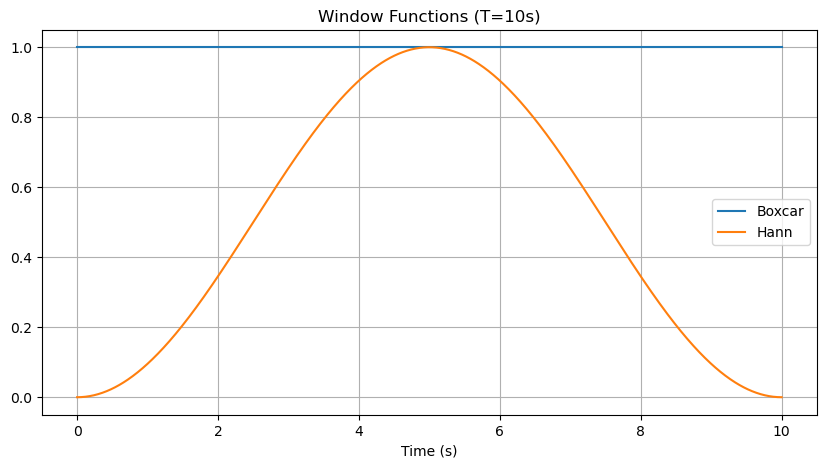

In [64]:
# Question 2, part a
T = 10
dt = 0.01
t_window = np.arange(0, T + dt, dt)

boxcar = np.ones_like(t_window)
hann = 0.5 * (1 - np.cos(2 * np.pi * t_window / T))

plt.figure(figsize=(10, 5))
plt.plot(t_window, boxcar, label='Boxcar')
plt.plot(t_window, hann, label='Hann')
plt.title('Window Functions (T=10s)')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True)
plt.show()

**(b) [2 points]** Calculate the Fourier transform of both functions using `numpy.fft`.
    Pay extra attention to how you interpret the corresponding frequencies of output results from python. `fftshift` may be useful.
    Also pay attention to the length of the input signal (> 15s), as it dictates the frequency resolution for the spectrum.



In [65]:
# Code, look at part c.

**(c) [2 points]** Plot the Fourier transform of both functions in the appropriate frequency range on the same graph.


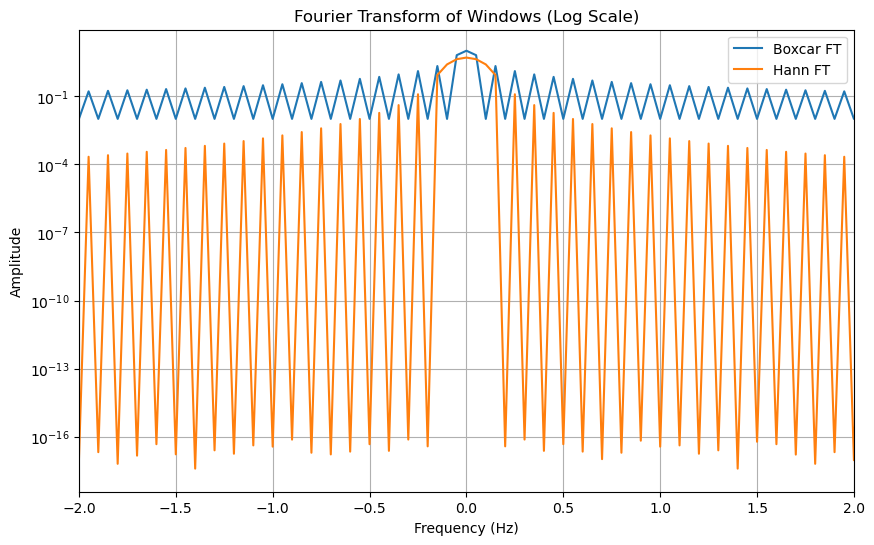

In [66]:
# Question 2, parts b and c
# To increase frequency resolution, we zero-pad the signals to > 15s
pad_t = np.arange(0, 20, dt)
boxcar_pad = np.zeros_like(pad_t)
hann_pad = np.zeros_like(pad_t)

boxcar_pad[:len(boxcar)] = boxcar
hann_pad[:len(hann)] = hann

# FFT
B_box = fftshift(fft(boxcar_pad)) * dt
B_hann = fftshift(fft(hann_pad)) * dt
freqs_win = fftshift(fftfreq(len(pad_t), d=dt))

plt.figure(figsize=(10, 6))
plt.plot(freqs_win, np.abs(B_box), label='Boxcar FT')
plt.plot(freqs_win, np.abs(B_hann), label='Hann FT')
plt.xlim(-2, 2)
plt.yscale('log')
plt.title('Fourier Transform of Windows (Log Scale)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

**(d) [2 points]** Based on the FTs, comment on the effect of truncating a continuous time series by either window on its frequency spectrum $G(\omega)$ compared to the original spectrum $F(\omega)$.




Truncating a signal in time is a convolution in the frequency domain. The original spectrum $F(\omega)$ is convolved with the FT of the window. 
* The **Boxcar** window causes significant "spectral leakage" due to its high side-lobes (seen in the sinc-like pattern). It stays big when far from 0.
* The **Hann** window reduces this leakage by having much smaller side-lobes, though its central peak is wider, slightly reducing frequency resolution.

**(e) [2 points]** Speculate on the advantages and disadvantages of boxcar and Hann window functions for truncation.


* **Boxcar:**
    * *Advantage:* Best frequency resolution (narrowest main lobe).
    * *Disadvantage:* High spectral leakage (high side-lobes) which can hide small signals near large peaks.
* **Hann:**
    * *Advantage:* Very low spectral leakage; better for identifying weak signals in the presence of noise or other strong frequencies.
    * *Disadvantage:* Lower frequency resolution (wider main lobe).

***

## Question 3

The simulation of a voltage measurement is given in the datafile `wave_signal.csv`. This measurement was made from a circuit built to take 12V of DC voltage and produce an oscillation. You will analyze the signal to extract information about the signal and decide between two alternative models of the process creating the signal.

**(a) [3 points]** Using the FFT functions, calculate the amplitude, frequency (or period), and phase offset of the waves that dominate this signal. For this question, it should be safe to ignore waves with amplitudes below about 0.1V.

Detected Waves:
Freq: 0.00 Hz, Amp: 12.00 V, Phase: 0.00 rad
Freq: 150.00 Hz, Amp: 2.00 V, Phase: -0.57 rad


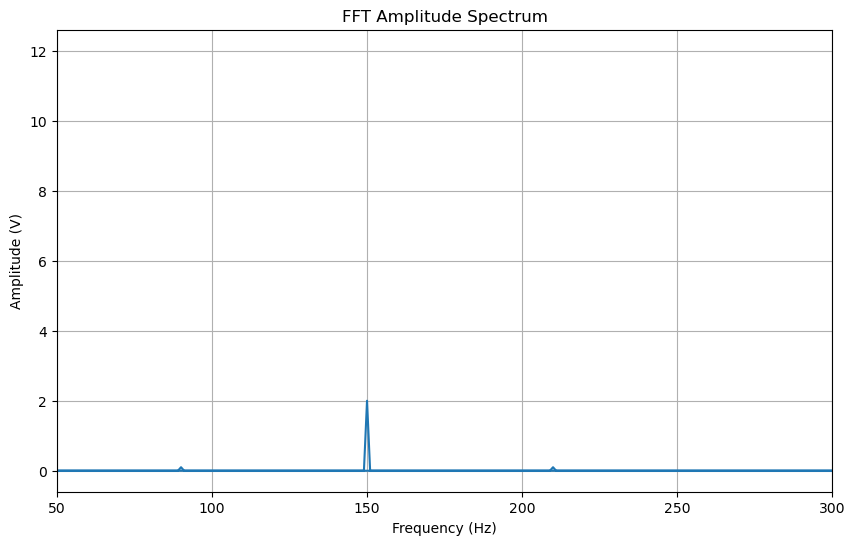

In [67]:
# Question 3, part a
import pandas as pd

data1 = pd.read_csv('data/wave_signal.csv')
t_s = data1['time'].values
v_s = data1['signal'].values
dt_s = t_s[1] - t_s[0]

# Perform FFT
V_fft = fft(v_s)
freqs_s = fftfreq(len(t_s), d=dt_s)

# Amplitudes (normalized)
amps = 2 * np.abs(V_fft) / len(t_s)
# Handle DC component
amps[0] = amps[0] / 2 

# Find peaks > 0.1V
mask = (amps > 0.1) & (freqs_s >= 0)
peak_freqs = freqs_s[mask]
peak_amps = amps[mask]
peak_phases = np.angle(V_fft[mask])

print("Detected Waves:")
for f, a, p in zip(peak_freqs, peak_amps, peak_phases):
    print(f"Freq: {f:.2f} Hz, Amp: {a:.2f} V, Phase: {p:.2f} rad")

plt.figure(figsize=(10, 6))
plt.plot(freqs_s, amps)
plt.title('FFT Amplitude Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V)')
plt.xlim(50, 300) # Limiting range to see the peak clearly
plt.grid(True)

**(b) [3 points]** Using the waves you found in part a, reconstruct the signal and plot both the original and recreated signal. Don't use the inverse FFT to reconstruct the signal.



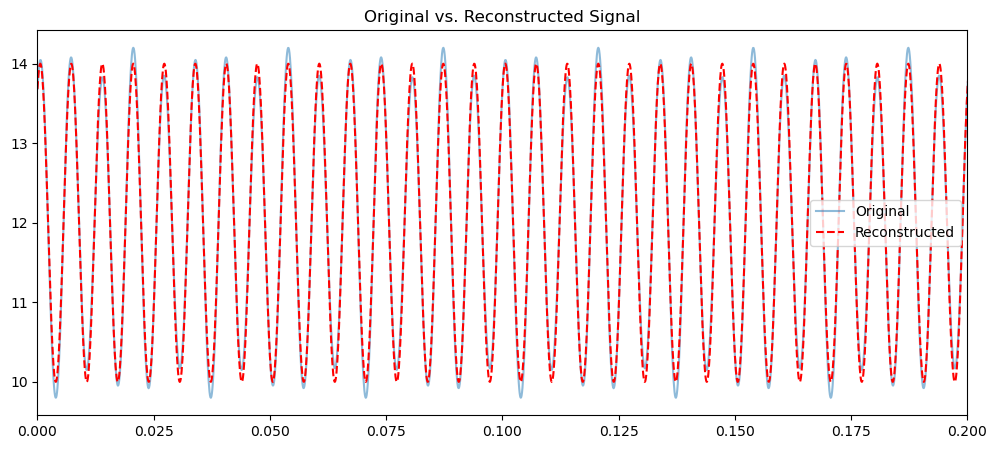

In [68]:
# Question 3, part b
# Reconstruct: V(t) = sum(A * cos(2*pi*f*t + phase))
v_recon = np.zeros_like(t_s)
for f, a, p in zip(peak_freqs, peak_amps, peak_phases):
    # Using the standard Fourier series reconstruction
    # Note: np.angle returns phase for e^(i*theta), which matches cos(x+p) logic
    v_recon += a * np.cos(2 * np.pi * f * t_s + p)

plt.figure(figsize=(12, 5))
plt.plot(t_s, v_s, label='Original', alpha=0.5)
plt.plot(t_s, v_recon, 'r--', label='Reconstructed')
plt.xlim(0, 0.2) # Zoom closer to see the fit
plt.title('Original vs. Reconstructed Signal')
plt.legend()
plt.show()

**(c) [3 points]** After disconnecting the power source from the circuit being measured, a new measurement of the power supply was made and suggested the power supply had a small variation in output voltage at the 60Hz frequency of the building electrical circuit. Calculate the amplitude, frequency, and phase offset of the waves in the experiment, accounting for a possible variation in the power supply voltage.

In [69]:

pos_mask = freqs_s >= 0
freqs_pos = freqs_s[pos_mask]
amps_pos = amps[pos_mask]

carrier_idx = np.argmax(amps_pos[1:]) + 1 

amplitude = amps_pos[carrier_idx]
frequency = freqs_pos[carrier_idx]
phase_offset = np.angle(V_fft[carrier_idx])

#Output results
print(f"--- Experiment Wave Parameters (60Hz Variation Accounted For) ---")
print(f"Frequency:    {frequency:.2f} Hz")
print(f"Amplitude:    {amplitude:.4f}")
print(f"Phase Offset: {phase_offset:.4f} rad")

--- Experiment Wave Parameters (60Hz Variation Accounted For) ---
Frequency:    150.00 Hz
Amplitude:    2.0000
Phase Offset: -0.5708 rad


**(d) [2 points]** You should now have two solutions for the same dataset. Is there any way that you could determine which solution is correct from the dataset alone? If so, how, and if not, what information is/was needed to decide between the two possible solutions.



If I was just given the dataset, we might be able to wager a guess that there was something odd about 60Hz difference between the peak frequency and the two much smaller peaks next to it, but we couldn't know for sure.

In context, if there was a problem at with 60Hz, we needed to know that that a 60Hz signal was an unintended artifact of the power supply, rather than an intentional part of the oscillation signal.

**(e) [1 point]** The measurement was repeated in the `wave_signal2` dataset. Plot the data and the fourier decomposition for this dataset. Compare the decompositions of the two signals and suggest a possible cause.

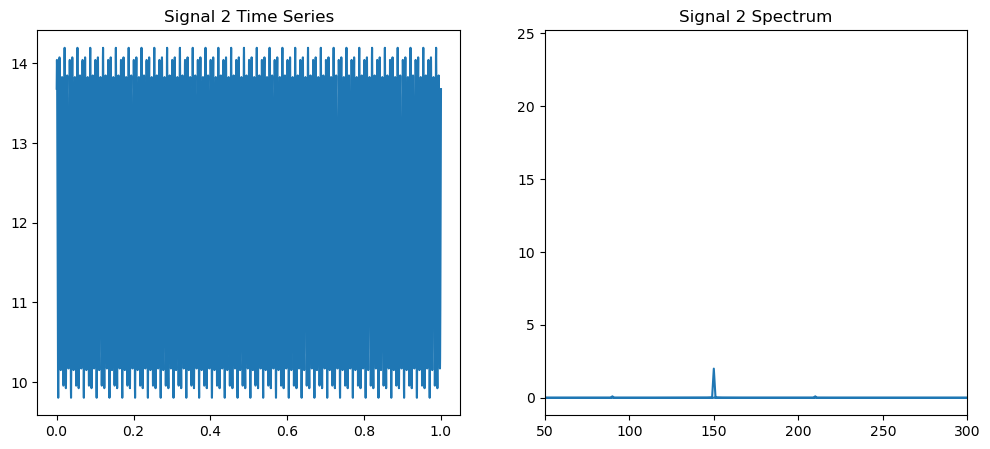

In [70]:
# Question 3, part e
data2 = pd.read_csv('data/wave_signal2.csv')
t_s2 = data2['time'].values
v_s2 = data2['signal'].values

V_fft2 = fft(v_s2)
amps2 = 2 * np.abs(V_fft2) / len(t_s2)
freqs_s2 = fftfreq(len(t_s2), d=t_s2[1]-t_s2[0])

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_s2, v_s2)
plt.title('Signal 2 Time Series')
plt.subplot(1, 2, 2)
plt.plot(freqs_s2, amps2)
plt.xlim(50, 300)
plt.title('Signal 2 Spectrum')
plt.show()

# Discussion: Compare peaks of data1 and data2 to see if 60Hz is consistent.

Upon comparing the spectra, we can notice tiny tiny bumps in the same frequencies, + or - 60 from the peak 150. Since this is true across different datasets while other signal peaks shift or vary, it suggests the 60Hz is indeed external noise (power supply leakage).

***

## Question 4

Liquids have no fixed internal structure. Yet they do have some short range order in the sense that they have preferred intermolecular spacings, which are determined by the locations of minima in the intermolecular potentials. The microscopic structure of liquids is often characterized by a quantity known as the Radial Distribution Function $g(r)$, which is essentially the probability that a molecule has a neighbouring molecule at distance r (Relative to the average probability, which means that $g(r)$ tends to 1 at large r, where the neighbour is too far away to feel any interaction.). Typically $g(r)$ shows a value that approaches zero at small r since molecules cannot occupy the same space; it also shows a peak at the preferred distance of nearest neighbours, and secondary peaks at preferred distances of more distant neighbours. If a suitable collimated beam of particles (e.g. X-rays or neutrons) is sent through a sample of the liquid, some of the particles are scattered. The number of particles scattered through a given angle is related to the Fourier Transform of $g(r)$ evaluated at the wavenumber k corresponding to the transverse momentum transfer associated with that scattering angle. Kittel derives this relationship in Chapter 17 of Introduction to Solid State Physics. 

If this all sounds complicated, all you need to know here is that something called the Structure Factor $S(k)$ is effectively measured by looking at the scattered intensity as a function of scattering transverse wavenumber k (proportional to scattering angle), and that the Radial Distribution Function is related to it by
$$g(r)=1+\frac{1}{2\pi^{2}\rho r}\int_{0}^{\infty}k(S(k)-1)\sin(kr)dk$$
where $\rho$ is liquid number density (number of atoms per unit volume, computable from the three constants mentioned in the introduction), k is wavenumber, and r is radius.

**(a) [2 points]** You may have noticed some resemblance between the expression and the Fourier transform. First show that the integration part $\int_{0}^{\infty}k(S(k)-1)\sin(kr)dk$ can be rewritten as
$$p(r)=\int_{-\infty}^{\infty}\frac{1}{2i}k(S(k)-1)e^{ikr}dk.$$
The structure factor $S(k)$ is even, since there should be no reason why scattering intensity would be different for one direction (+k) compared to its opposite (-k). Using the fact that $S(k)$ is even may be useful.




Starting with the Sine Transform:

$\int_{0}^{\infty}k(S(k)-1)\sin(kr)dk$

Using $\sin(kr) = \frac{e^{ikr} - e^{-ikr}}{2i}$:

$= \int_{0}^{\infty} \frac{1}{2i} k(S(k)-1)e^{ikr} dk - \int_{0}^{\infty} \frac{1}{2i} k(S(k)-1)e^{-ikr} dk$

Since $S(k)$ is even and $k$ is odd, the product $k(S(k)-1)$ is odd. For an odd function $O(k)$, $\int_{0}^{\infty} O(k) e^{-ikr} dk = \int_{-\infty}^{0} -O(k') e^{ik'r} d(-k') = \int_{-\infty}^{0} O(k') e^{ik'r} dk'$.

Thus, the expression becomes:
$p(r) = \int_{-\infty}^{\infty} \frac{1}{2i} k(S(k)-1) e^{ikr} dk$.

**(b) [2 points]** Now we can make some connections between the Radial Transfer Function and the Fourier Transform, if we substitute $r\rightarrow t$ $k\rightarrow\omega$ What is the Fourier transform $P(k)$ of p(r)? Is $P(k)$ a real, imaginary or general complex function? Is it even or odd? How will these affect $p(r)?$ Is that what you expect? Plot $P(k)$ as a function of k ranging from $-10\mathring{A}^{-1}$ to $10\mathring{A}^{-1}$ based on argon.py (i.e. import and use the variables defined there). 

In constructing S(k) from 'argon.py', you should make an "even" array twice the length (minus 1) of YanData. YanData represents the structure factor (i.e. S(k)) for argon sampled at the dk defined in the 'argon.py' file. It's specifically $S(k)$ sampled from '$k=0$' to 'k=len(YanData)*dk', so create an even function out to the same length in the negative direction (i.e. the "k-axis" it's sampled on would be: '-(len(YanData)-1)*dk,...0,...,+(len(YanData)-1)*dk')





<>:15: SyntaxWarning: invalid escape sequence '\A'
<>:15: SyntaxWarning: invalid escape sequence '\A'
C:\Users\User\AppData\Local\Temp\ipykernel_44980\3092945708.py:15: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('k ($\AA^{-1}$)')


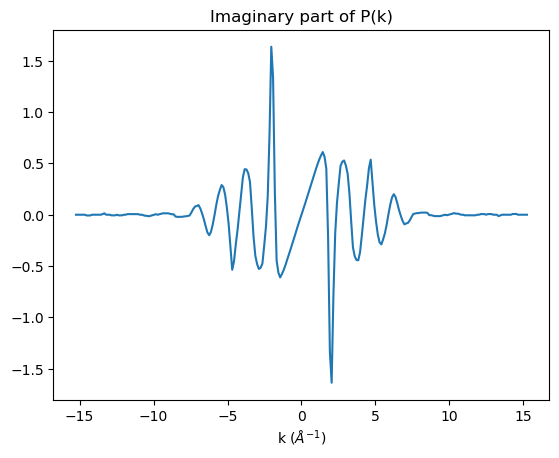

In [71]:
# Question 4, part b
from argon import YanData, dk

N = len(YanData)
# Create even S(k)
k_pos = np.arange(N) * dk
S_even = np.concatenate([YanData[::-1], YanData[1:]])
k_axis = np.concatenate([-k_pos[::-1], k_pos[1:]])

# P(k) = (1/2i) * k * (S(k) - 1)
Pk = (1/(2j)) * k_axis * (S_even - 1)

plt.plot(k_axis, Pk.imag)
plt.title('Imaginary part of P(k)')
plt.xlabel('k ($\AA^{-1}$)')
plt.show()

**(c) [2 points]** Write a Python function `[gn, rn] = RDFcalc (S, dk, rho)` to calculate Radial Distribution Function $g(r)$ from Structure Factor $S(k)$ data, sampled at dk, and density $\rho$, and output the RDF vector $g_{n}$ and its corresponding radial distance vector $r_{n}$. 

For Python '`fft()`' and '`ifft()`' functions, realize that the values of the Fourier Transform corresponding to negative frequencies are stored in the second half of the arrays given to ('`ifft`') or obtained from it ('`fft`'). You also have to study the difference between the DFT and FT to multiply the right factors.



In [72]:
# Question 4, part c
from numpy.fft import ifft, fftshift

def RDFcalc(S, dk, rho):
    N_full = len(S)
    # P(k) = (1/2i) * k * (S(k) - 1)
    # Shift k_axis so 0 is in the middle to match your even S
    k_axis = (np.arange(N_full) - (N_full // 2)) * dk
    Pk = (1 / (2j)) * k_axis * (S - 1)
    
    p_r_complex = ifft(fftshift(Pk)) * (N_full * dk / (2 * np.pi))
    
    # Radius vector: dr = 2*pi / (total k range)
    dr = (2 * np.pi) / (N_full * dk)
    rn = np.arange(N_full) * dr
    
    # g(r) = 1 + (1 / (2 * pi^2 * rho * r)) * p(r)
    with np.errstate(divide='ignore', invalid='ignore'):
        gn = 1 + np.real(p_r_complex) / (2 * np.pi**2 * rho * rn)
    
    gn[0] = 0 # Boundary condition
    return gn, rn

**(d) [2 points]** With the data provided in argon.py, compute the corresponding Radial Distribution Function $g(r)$. Plot your results for r from 0 to $20\mathring{A}$. Over what range of radius can you trust your result? 

To check if your results make sense, recall that $g(r)$ is related to the probability that a molecule has a neighbouring molecule at distance r, therefore, should be close to 0 when $r\rightarrow 0$, i.e. two molecules can not occupy the same space, and you can set $g(r=0)=0$. Recall $\lim_{r\to\infty}g(r)=1$ Also note the unit $\rho$ used in $g(r)$ formula (6).



<>:26: SyntaxWarning: invalid escape sequence '\A'
<>:30: SyntaxWarning: invalid escape sequence '\A'
<>:26: SyntaxWarning: invalid escape sequence '\A'
<>:30: SyntaxWarning: invalid escape sequence '\A'
C:\Users\User\AppData\Local\Temp\ipykernel_44980\2346984885.py:26: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Radius $r$ ($\AA$)')
C:\Users\User\AppData\Local\Temp\ipykernel_44980\2346984885.py:30: SyntaxWarning: invalid escape sequence '\A'
  plt.annotate(f'Peak: ({peak_r:.2f} $\AA$, {peak_g:.2f})',


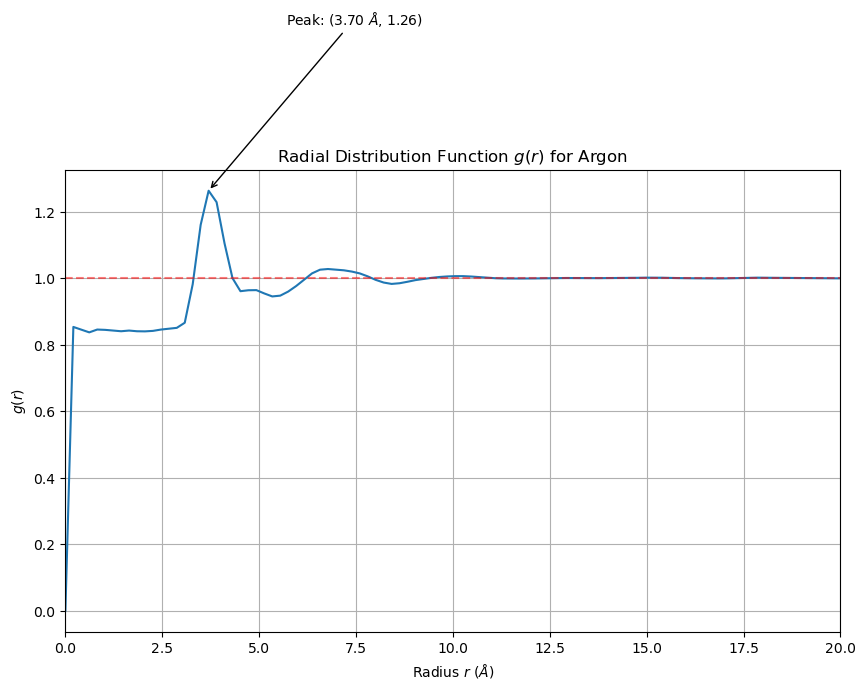

In [73]:
# Question 4, part d
from argon import YanData, dk, massRho, molWeight, Navogadro

# Calculate number density rho (atoms per cubic Angstrom)
# rho = (mass_density * Na) / molecular_weight
rho = (massRho * Navogadro) / molWeight * 1e-24 # 1e-24 converts cm^3 to Angstrom^3

# Construct even S(k)
N = len(YanData)
S_even = np.concatenate([YanData[::-1], YanData[1:]])

gn, rn = RDFcalc(S_even, dk, rho)

peak_index = np.argmax(gn)
peak_r = rn[peak_index]
peak_g = gn[peak_index]




plt.figure(figsize=(10, 6))
plt.plot(rn, gn)
plt.axhline(1, color='r', linestyle='--', alpha=0.5)
plt.xlim(0, 20)
plt.title('Radial Distribution Function $g(r)$ for Argon')
plt.xlabel('Radius $r$ ($\AA$)')
plt.ylabel('$g(r)$')
plt.grid(True)

plt.annotate(f'Peak: ({peak_r:.2f} $\AA$, {peak_g:.2f})', 
             xy=(peak_r, peak_g), 
             xytext=(peak_r + 2, peak_g + 0.5), # Adjust position to avoid the line
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.show()

**(e) [2 points]** From the $g(r)$ you computed, estimate the average molecular radius $R_{a}$ of liquid argon. Give your reasoning and state what accuracy you can justify for your estimation.




**Estimation of average molecular radius $R_a$:**
The first peak of $g(r)$ represents the preferred distance of the nearest neighbors. The location of this peak corresponds to the diameter of the molecule (or the equilibrium distance between two centers). Therefore, $R_a \approx \text{Peak Position} / 2$. 

Looking at the plot, the first peak is at approximately $3.7 \AA$, suggesting a molecular radius of $\sim 1.85 \AA$. The accuracy is limited by the sampling $dr$ of our Fourier transform.

**(f) [2 points]** Now we explore the effect of sampling range. Yan sampled in wavenumber k out to $k_{max}=15.24\mathring{A}^{-1}$, and he could have saved himself work by not collecting as much data, i.e., reducing $k_{max}$. But how much could he have reduced the sampling length $k_{max}$, while still seeing distinct peaks in the Radial Distribution Function? Also explain theoretically what you observe. 

Plot on top of the $g(r)$ obtained in part 4, the $g(r)$'s you compute for a series of $k_{max}$ values. You can try half $k_{max}$ each time to look for changes. For the theoretical explanations for part 6 and 7, realize the interchangability of $t\leftrightarrow\omega$ ($r\leftrightarrow k$).



<>:20: SyntaxWarning: invalid escape sequence '\A'
<>:20: SyntaxWarning: invalid escape sequence '\A'
C:\Users\User\AppData\Local\Temp\ipykernel_44980\1493656919.py:20: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Radius $r$ ($\AA$)')


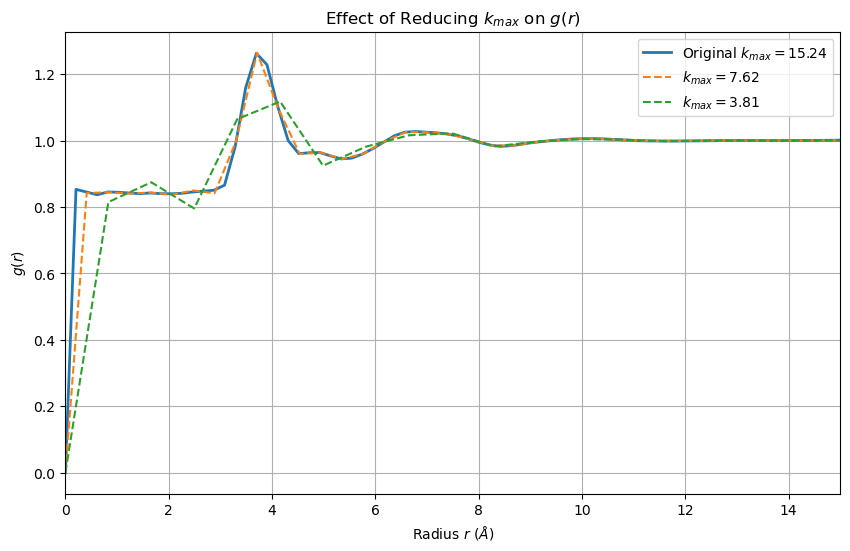

In [74]:
# Question 4, part f
k_max_original = (N - 1) * dk
k_max_values = [k_max_original, k_max_original / 2, k_max_original / 4]

plt.figure(figsize=(10, 6))
# Plot original g(r) for comparison
plt.plot(rn, gn, label=f'Original $k_{{max}} = {k_max_original:.2f}$', linewidth=2)

for km in k_max_values[1:]:
    # Sub-sample the even S_even array based on k_max
    mask = np.abs(k_axis) <= km
    S_sub = S_even[mask]
    
    # Calculate new g(r)
    gn_sub, rn_sub = RDFcalc(S_sub, dk, rho)
    plt.plot(rn_sub, gn_sub, '--', label=f'$k_{{max}} = {km:.2f}$')

plt.xlim(0, 15)
plt.title('Effect of Reducing $k_{max}$ on $g(r)$')
plt.xlabel('Radius $r$ ($\AA$)')
plt.ylabel('$g(r)$')
plt.legend()
plt.grid(True)
plt.show()

# Theoretical Explanation:
# Reducing k_max limits the high-frequency information. 
# In the r-domain, this acts as a low-pass filter, broadening the peaks 
# and reducing the ability to resolve closely spaced molecular shells. [cite: 198, 199]

**(g) [2 points]** To explore the effect of data sampling, let's assume Yan decided to save his work by sampling less often (i.e. increasing dk). How large a dk can he use to be able to still recover the first two peaks clearly? State your answers and a theoretical justification for what you expect to see if you increase dk too much. 

Plot on top of the $g(r)$ obtained from 'argon.py' data, the $g(r)$'s you obtain when you sub-sample the same dataset. Try doubling dk each time to observe the effect of coarser sampling.

<>:23: SyntaxWarning: invalid escape sequence '\A'
<>:23: SyntaxWarning: invalid escape sequence '\A'
C:\Users\User\AppData\Local\Temp\ipykernel_44980\1144742677.py:23: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Radius $r$ ($\AA$)')


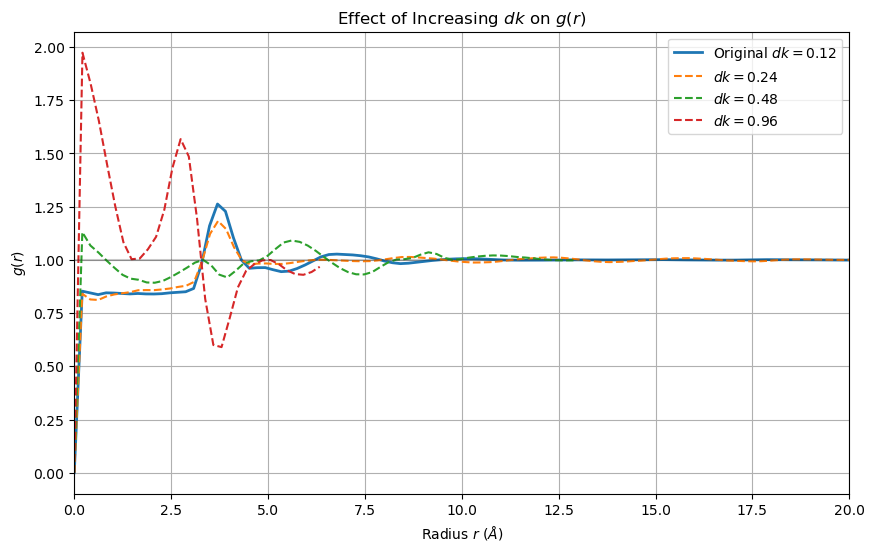

In [75]:
# Question 4, part g
dk_multipliers = [1, 2, 4, 8]

plt.figure(figsize=(10, 6))
# Plot original for comparison
plt.plot(rn, gn, label='Original $dk = 0.12$', linewidth=2)

for m in dk_multipliers[1:]:
    # Sub-sample YanData by taking every m-th point
    Yan_sub = YanData[::m]
    new_dk = dk * m
    
    # Reconstruct even S(k)
    S_even_sub = np.concatenate([Yan_sub[::-1], Yan_sub[1:]])
    
    # Calculate new g(r)
    gn_sub, rn_sub = RDFcalc(S_even_sub, new_dk, rho)
    plt.plot(rn_sub, gn_sub, '--', label=f'$dk = {new_dk:.2f}$')

plt.xlim(0, 20)
plt.axhline(1, color='k', alpha=0.2)
plt.title('Effect of Increasing $dk$ on $g(r)$')
plt.xlabel('Radius $r$ ($\AA$)')
plt.ylabel('$g(r)$')
plt.legend()
plt.grid(True)
plt.show()

# Theoretical Justification:
# According to the Nyquist-Shannon sampling theorem, increasing dk decreases 
# the range of r that can be uniquely determined (r_max ~ pi/dk). 
# If dk is too large, aliasing occurs, and the g(r) signal wraps around, 
# distorting the physical peaks.

***

## Question 5

The surface air pressure on Mars has been measured by the Curiosity rover (https://science.nasa.gov/mission/msl-curiosity/) since 2012 - part of that dataset is available in the `rems_data_408.csv` dataset. The dataset provides three columns of information, msd, ls, and pressure.
* MSD, or Mars Solar Date, is designed to be similar to the Earth calendar Modified Julian Date (MJD). 1 MSD is 1 24 solar hour period on Mars
* ls (heliocentric longitude, or $L_{s}$) is the location of Mars in its orbit from Northern Vernal Equinox (roughly the start of northern spring). The measurement is in degrees from $0^{\circ}$ to $360^{\circ}$.
* Pressure is the air pressure measured by the sensor in Pascal (Pa).

While this dataset is essentially real data from the Mars rover it has been processed to produce a regular dataset with a reasonably well behaved Fourier Transform. In the process, some of the true variability has been masked and gaps in the data have been smoothed over. 

The atmosphere of Mars is mostly carbon dioxide, with trace amounts of nitrogen, argon, and other gases. During the winter, in either hemisphere, the temperature near the surface is cold enough for carbon dioxide to condense out of the atmosphere is snow and deposit onto the surface. The seasonal deposit of carbon dioxide ice is sublimated in spring as the Sunlight warms the surface and sublimes the solid carbon dioxide ice directly into gas (in some parts of the south pole, part of this process happens when trapped carbon dioxide erupts through the ice sheet, causing surface cracks, https://www.esa.int/Science_Exploration/Space_Science/Mars_Express/Signs_of_spiders_from_Mars). 

In addition to the annual cycle of condensing and subliming carbon dioxide, the air pressure responds to the daily heating from the Sun as it passes overhead and weather patterns that appear as cycles of low and high pressure passing over the rover.

**(a) [2 points]** Load and plot the raw pressure data from the Curiosity rover from the included dataset.



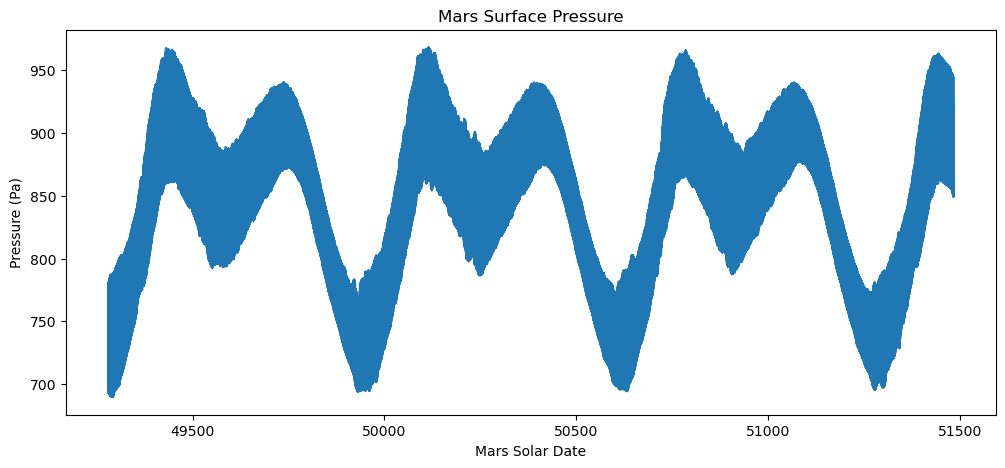

In [76]:
# Question 5, part a
mars_data = pd.read_csv('data/rems_data_408.csv')
plt.figure(figsize=(12, 5))
plt.plot(mars_data['msd'], mars_data['pressure'])
plt.xlabel('Mars Solar Date')
plt.ylabel('Pressure (Pa)')
plt.title('Mars Surface Pressure')
plt.show()

**(b) [5 points]** Fit the annual cycle and any sub-annual harmonics you find appropriate from this dataset. The Martian calendar is defined by a parameter called Heliocentric Longitude $(L_{S})$ measured as the number of degrees around the orbit, starting from Northern Vernal Equinox at $L_{S}=0^{\circ}$ (the start of spring), and counting up through Northern Summer Solstice $(L_{S}=90^{\circ})$, Northern Autumnal Equinox $(L_{S}=180^{\circ})$, and Northern Winter Solstice $(L_{S}=270^{\circ})$. Find the approximate time of the two minima and maxima that you find each year.



Primary Maxima at Ls: [ 52.61261261 259.45945946]
Primary Minima at Ls: [154.95495495 339.0990991 ]


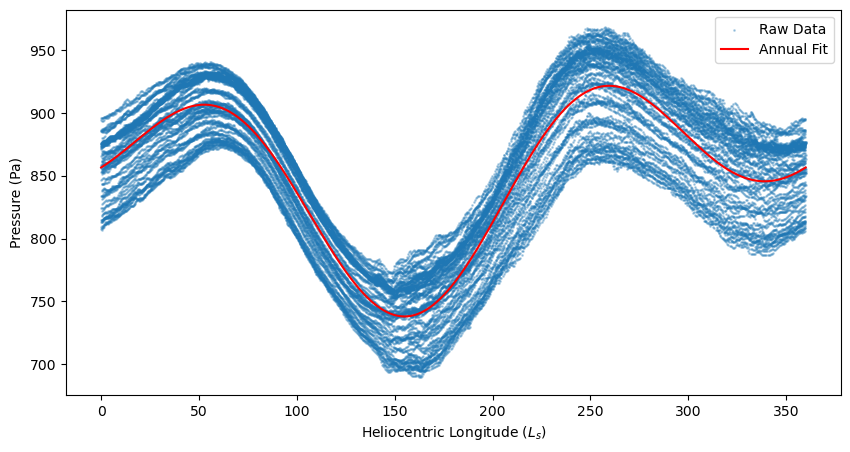

In [77]:
# Question 5, part b
from scipy.optimize import curve_fit

def annual_model(ls, a1, p1, a2, p2, offset):
    rad = np.radians(ls)
    return a1 * np.sin(rad + p1) + a2 * np.sin(2 * rad + p2) + offset

# Initial guess for the optimizer
p0 = [100, 0, 50, 0, 800]
params, _ = curve_fit(annual_model, mars_data['ls'], mars_data['pressure'], p0=p0)

# Generate high-res Ls for finding extrema
ls_fine = np.linspace(0, 360, 1000)
press_fit = annual_model(ls_fine, *params)

# Find indices of max and min
from scipy.signal import find_peaks
peaks, _ = find_peaks(press_fit)
mins, _ = find_peaks(-press_fit)

print(f"Primary Maxima at Ls: {ls_fine[peaks]}")
print(f"Primary Minima at Ls: {ls_fine[mins]}")

plt.figure(figsize=(10, 5))
plt.scatter(mars_data['ls'], mars_data['pressure'], s=1, alpha=0.3, label='Raw Data')
plt.plot(ls_fine, press_fit, color='red', label='Annual Fit')
plt.xlabel('Heliocentric Longitude ($L_s$)')
plt.ylabel('Pressure (Pa)')
plt.legend()
plt.show()

**(c) [5 points]** After removing the annual cycle component, find the amplitude and phase of the diurnal through quad-diurnal waves (i.e. once per day through four-times per day). These waves change throughout the year so you will need to use a method that can calculate the Fourier components over short periods of time, for example by using a window function to select periods before calculate the FFT. Plot the wave amplitudes in one plot along with the residual signal after removing these components. Plot the hour of first maximum (related to the phase) of each wave in a second plot.

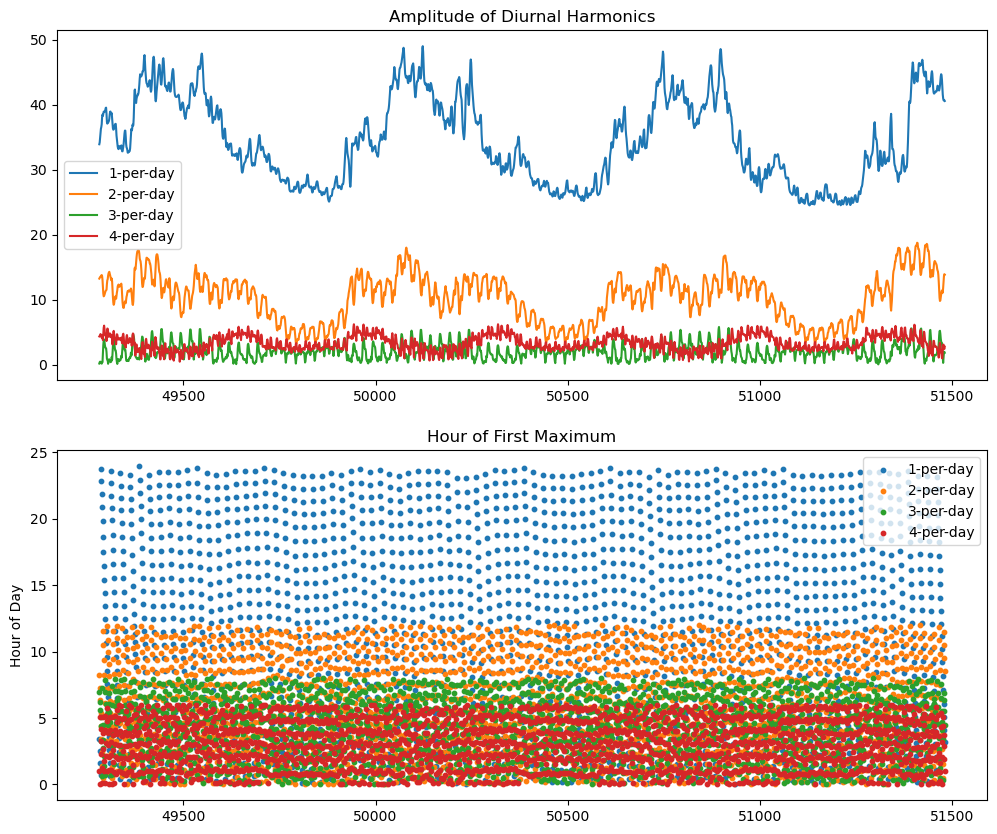

In [78]:
# Question 5, part c

mars_data['residual'] = mars_data['pressure'] - annual_model(mars_data['ls'], *params)

def get_diurnal_components(data, window_size=50):
    msd = data['msd'].values
    res = data['residual'].values
    times, amps = [], {1: [], 2: [], 3: [], 4: []}
    phases = {1: [], 2: [], 3: [], 4: []}
    
    for i in range(0, len(msd) - window_size, window_size // 2):
        chunk = res[i : i + window_size]
        t_chunk = msd[i : i + window_size]
        
        yf = fft(chunk)
        xf = fftfreq(len(chunk), d=(t_chunk[1]-t_chunk[0]))
        
        for h in range(1, 5):
            idx = np.argmin(np.abs(xf - h))
            amps[h].append(2 * np.abs(yf[idx]) / len(chunk))
            # Phase to hour: phase is in rad. 
            # Hour = (-phase / (2*pi*f)) * 24 
            p = np.angle(yf[idx])
            hour_max = (-p / (2 * np.pi * h)) * 24 % (24/h)
            phases[h].append(hour_max)
        
        times.append(np.mean(t_chunk))
    return np.array(times), amps, phases

times_d, h_amps, h_phases = get_diurnal_components(mars_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
for h in range(1, 5):
    ax1.plot(times_d, h_amps[h], label=f'{h}-per-day')
    ax2.scatter(times_d, h_phases[h], s=10, label=f'{h}-per-day')

ax1.set_title('Amplitude of Diurnal Harmonics')
ax1.legend()
ax2.set_title('Hour of First Maximum')
ax2.set_ylabel('Hour of Day')
ax2.legend()
plt.show()